In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import scanpy as sc
import anndata as ad
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')

# Input/Output paths
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION"
PLOTS_DIR = "/gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/gene_expression/plots"

# if doesn't exist, create it
if not os.path.exists(PLOTS_DIR):
    os.makedirs(PLOTS_DIR)

In [2]:
# Load data
# Gene expression data
GE_ANNDATA_scVI_PATH = f"{BASE_DIR}/scVI/ge_adata_with_scvi_model_latent_20_20000_2025-10-09.h5ad"

print(f"Loading scVI data from {GE_ANNDATA_scVI_PATH}")
ge_adata = ad.read_h5ad(GE_ANNDATA_scVI_PATH)

Loading scVI data from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/scVI/ge_adata_with_scvi_model_latent_20_20000_2025-10-09.h5ad


In [3]:
# Splicing data 
SPLICE_ANNDATA_PATH = f"{BASE_DIR}/MODEL_INPUT/102025/aligned_splicing_data_20251003_010354.h5ad"
print(f"Loading splicing raw input data from {SPLICE_ANNDATA_PATH}")
splice_adata = ad.read_h5ad(SPLICE_ANNDATA_PATH)

Loading splicing raw input data from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/102025/aligned_splicing_data_20251003_010354.h5ad


### Main to-do

1. Ensure known marker genes check out in terms of their normalized expression from scVI 
2. Clean cell types (broad and medium), double check tissue labels are clean, age, sex... uniform labels 
3. Label p16 expression 
4. Make sure junctions are ready for modeling - no cells with no junctions detected and no junctions with no cells detected 
5. Look at gene coverage (counts) versus junction counts to get sense of this correlation or total junction counts in gene per cell versus total gene counts? 

In [4]:
# Get lists of marker gene and plot the normalized expression values 
ge_adata, splice_adata

(AnnData object with n_obs × n_vars = 76986 × 11545
     obs: 'donor', 'sex', 'age', 'dataset', 'tissue', 'cell_type', 'broad_cell_type', 'library_size', 'batch', 'cell_id_backup', 'cell_id_index', 'cell_id_clean', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_is_rRNA', 'log1p_total_counts_is_rRNA', 'pct_counts_is_rRNA', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
     var: 'gene_symbol', 'gene_id', 'gene_name', 'mean_transcript_length', 'mean_intron_length', 'num_transcripts', 'gene_biotype', 'clean_gene_id', 'is_rRNA', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'RBP_gene', 'Aging_gene', 'is_hvg', 'is_rbp', 'is_aging'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'broad_cell_type_colors', 'gene_selection', 'leiden_scVI', 'leiden_scVI_colors', 'leiden_scVI_params', 'neighbors', 'scvi_linear', 'umap'
     obsm: 'X_normalized_scVI_linear', 'X_scVI_linear', '

In [5]:
# Load the aging gene datasets
aging_genes_human = "/gpfs/commons/groups/knowles_lab/Karin/HAGR/GenAge/human/genage_human.csv"
senes_genes_human = "/gpfs/commons/groups/knowles_lab/Karin/HAGR/CellAge/cellage3.tsv"

aging = pd.read_csv(aging_genes_human)
senes = pd.read_csv(senes_genes_human, sep="\t")
high_conf_aging = aging[aging["why"].isin(["human", "model,human_link"])]

# Remove old columns from ge_adata.var
ge_adata.var = ge_adata.var.drop(columns=['Aging_gene', 'is_aging'], errors='ignore')

# Create new boolean columns based on gene symbols
aging_gene_symbols = set(aging['symbol'].str.upper())
senes_gene_symbols = set(senes['Gene symbol'].str.upper())
high_conf_aging_symbols = set(high_conf_aging['symbol'].str.upper())

ge_adata.var['aging_gene'] = ge_adata.var['gene_symbol'].str.upper().isin(aging_gene_symbols)
ge_adata.var['senescence_gene'] = ge_adata.var['gene_symbol'].str.upper().isin(senes_gene_symbols)
ge_adata.var['high_confidence_aging_gene'] = ge_adata.var['gene_symbol'].str.upper().isin(high_conf_aging_symbols)

print(f"Gene Expression Data: {ge_adata.var['aging_gene'].sum()} aging, "
      f"{ge_adata.var['senescence_gene'].sum()} senescence, "
      f"{ge_adata.var['high_confidence_aging_gene'].sum()} high-confidence aging genes")

# Transfer labels to splice_adata
gene_labels = ge_adata.var[['gene_name', 'aging_gene', 'senescence_gene', 'high_confidence_aging_gene']].drop_duplicates(subset='gene_name').set_index('gene_name')

splice_adata.var['aging_gene'] = splice_adata.var['gene_name'].map(gene_labels['aging_gene']).fillna(False).astype(bool)
splice_adata.var['senescence_gene'] = splice_adata.var['gene_name'].map(gene_labels['senescence_gene']).fillna(False).astype(bool)
splice_adata.var['high_confidence_aging_gene'] = splice_adata.var['gene_name'].map(gene_labels['high_confidence_aging_gene']).fillna(False).astype(bool)

print(f"Splice Data: {splice_adata.var['aging_gene'].sum()} junctions from aging genes, "
      f"{splice_adata.var['senescence_gene'].sum()} from senescence genes, "
      f"{splice_adata.var['high_confidence_aging_gene'].sum()} from high-confidence aging genes")

Gene Expression Data: 242 aging, 685 senescence, 3 high-confidence aging genes
Splice Data: 2664 junctions from aging genes, 7732 from senescence genes, 57 from high-confidence aging genes


In [6]:
ge_adata.var_names = ge_adata.var["gene_name"]

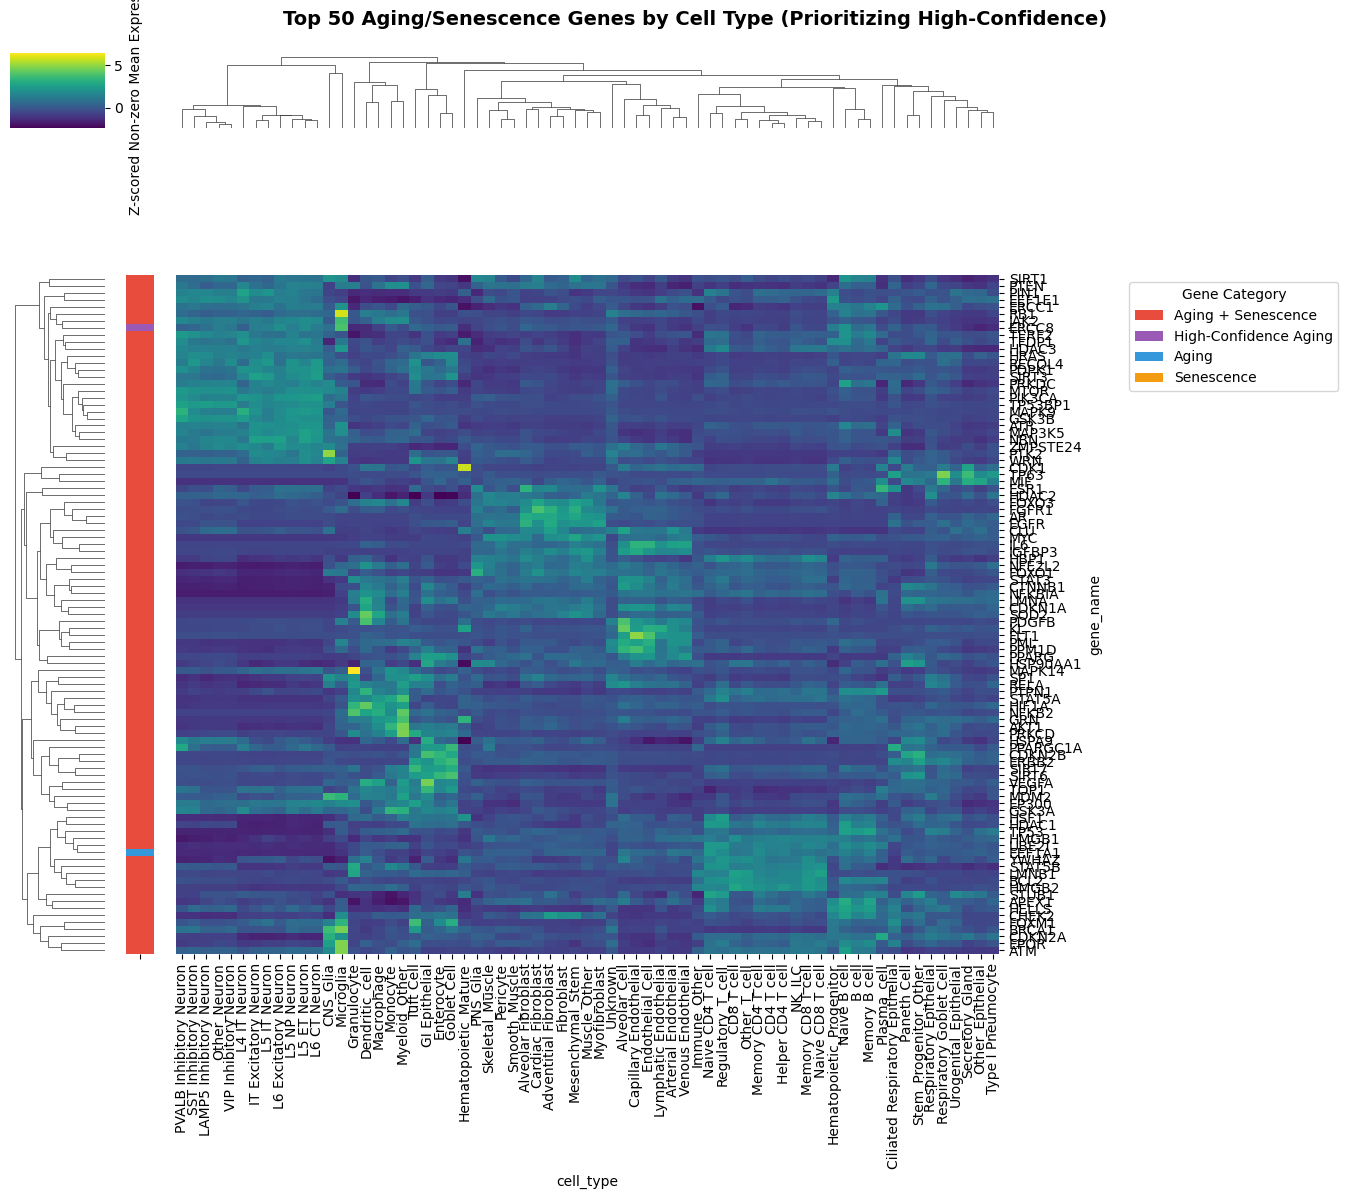


Analyzed 97 genes across 67 cell types

Gene category counts:
Aging + Senescence       95
High-Confidence Aging     1
Aging                     1
Name: count, dtype: int64

Priority genes included: 96
Priority genes: IL6, AR, EPOR, SIRT7, HSF1, EP300, CDK1, KL, TP63, PDGFB, PPARGC1A, FOXO3, EGFR, MAPK9, SIRT1, PPARG, AKT1, APEX1, LMNA, JAK2, STUB1, YWHAZ, HDAC1, HSPA9, STAT5A, FGFR1, FOXM1, SP1, STAT5B, MTOR, CDKN2A, TP53, PTK2, PTPN1, CDKN1A, BRCA1, PIN1, HMGB1, GSK3B, BCL2, SIRT6, TFDP1, HSP90AA1, VEGFA, HIF1A, MIF, CDKN2B, RB1, PRKDC, CLU, SOD2, RELA, UBE2I, LMNB1, PDPK1, HRAS, PML, MAP3K5, EEF1E1, PTEN, MYC, TERF2, IGFBP3, PRKCD, HMGB2, FLT1, ESR1, NFKB2, HBP1, GSK3A, NFE2L2, ERCC8, STAT3, HDAC2, PIK3CA, MDM2, RECQL4, CHEK2, SIRT3, ATM, CTNNB1, NBN, ERCC1, PPM1D, NFKBIA, ZMPSTE24, WRN, TP53BP1, ERBB2, FOXO1, ATR, HELLS, TOP1, GRN, MAPK14, HDAC3


In [7]:
# Select genes from aging/senescence categories
aging_or_senes_mask = (
    ge_adata.var['aging_gene'] | 
    ge_adata.var['senescence_gene'] | 
    ge_adata.var['high_confidence_aging_gene']
)

gene_names = ge_adata.var_names[aging_or_senes_mask]

# Get normalized expression
normalized_expr_full = ge_adata.obsm['X_normalized_scVI_linear']
normalized_expr = normalized_expr_full.iloc[:, aging_or_senes_mask.values]
normalized_expr.columns = gene_names

# Function to calculate non-zero mean
def nonzero_mean(x):
    nonzero = x[x > 0]
    return nonzero.mean() if len(nonzero) > 0 else 0

# Calculate non-zero mean by cell type
temp_df = normalized_expr.copy()
temp_df['cell_type'] = splice_adata.obs['medium_cell_type'].values
nonzero_mean_df = temp_df.groupby('cell_type').apply(
    lambda x: x.drop('cell_type', axis=1).apply(nonzero_mean)
).T

# Calculate mean expression across all cell types
overall_mean_expr = nonzero_mean_df.mean(axis=1).sort_values(ascending=False)

# Categorize all genes first
gene_categories_dict = {}
priority_genes = []  # High-confidence aging and aging+senescence genes

for gene in nonzero_mean_df.index:
    is_aging = ge_adata.var.loc[gene, 'aging_gene']
    is_senes = ge_adata.var.loc[gene, 'senescence_gene']
    is_high_conf = ge_adata.var.loc[gene, 'high_confidence_aging_gene']
    
    if is_aging and is_senes:
        gene_categories_dict[gene] = ('Aging + Senescence', '#E74C3C')
        priority_genes.append(gene)
    elif is_high_conf:
        gene_categories_dict[gene] = ('High-Confidence Aging', '#9B59B6')
        priority_genes.append(gene)
    elif is_aging:
        gene_categories_dict[gene] = ('Aging', '#3498DB')
    elif is_senes:
        gene_categories_dict[gene] = ('Senescence', '#F39C12')

# Start with all priority genes
genes_to_keep = priority_genes.copy()

# Add remaining genes from top 50 by expression until we reach 50 total
remaining_slots = 50 - len(genes_to_keep)
for gene in overall_mean_expr.index:
    if gene not in genes_to_keep:
        genes_to_keep.append(gene)
        if len(genes_to_keep) >= 50:
            break

# Filter the dataframe
nonzero_mean_df_filtered = nonzero_mean_df.loc[genes_to_keep]

# Create color lists for filtered genes
gene_categories = [gene_categories_dict[gene][0] for gene in genes_to_keep]
gene_colors = [gene_categories_dict[gene][1] for gene in genes_to_keep]

# Create color dataframe for rows
row_colors = pd.Series(gene_colors, index=genes_to_keep)

# Create the clustermap with row colors
g = sns.clustermap(
    nonzero_mean_df_filtered,
    cmap='viridis',
    z_score=0,
    figsize=(14, 12),
    cbar_kws={'label': 'Z-scored Non-zero Mean Expression'},
    yticklabels=True,
    xticklabels=True,
    row_colors=row_colors,
    dendrogram_ratio=0.1
)

plt.suptitle(f'Top 50 Aging/Senescence Genes by Cell Type (Prioritizing High-Confidence)', 
             y=0.995, fontsize=14, fontweight='bold')

# Create custom legend
legend_elements = [
    Patch(facecolor='#E74C3C', label='Aging + Senescence'),
    Patch(facecolor='#9B59B6', label='High-Confidence Aging'),
    Patch(facecolor='#3498DB', label='Aging'),
    Patch(facecolor='#F39C12', label='Senescence')
]

g.ax_heatmap.legend(handles=legend_elements, 
                    loc='upper left', 
                    bbox_to_anchor=(1.15, 1), 
                    frameon=True,
                    title='Gene Category')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nAnalyzed {len(genes_to_keep)} genes across {nonzero_mean_df_filtered.shape[1]} cell types")
print(f"\nGene category counts:")
print(pd.Series(gene_categories).value_counts())
print(f"\nPriority genes included: {len(priority_genes)}")
print(f"Priority genes: {', '.join(priority_genes)}")

In [8]:
splice_adata[splice_adata.obs["medium_cell_type"] == "Unknown"].obs

,cell_id,donor,sex,age,dataset,tissue,cell_type,broad_cell_type,cell_id_index,cell_id_clean,total_junction_reads,annotated_junction_reads,unannotated_junction_reads,n_detected_annotated_junctions,n_detected_unannotated_junctions,medium_cell_type,tissue_clean
cell_id_clean,,,,,,,,,,,,,,,,,
F1S4_160721_059_H01,F1S4_160721_059_H01,H200.1030,M,54,allen_brain,MTG,Endothelial,Unknown,5325,F1S4_160721_059_H01,31303,30073,1230,563,27,Unknown,Brain_MTG
F1S4_160721_090_H01,F1S4_160721_090_H01,H200.1030,M,54,allen_brain,MTG,Endothelial,Unknown,16850,F1S4_160721_090_H01,55679,54959,720,960,28,Unknown,Brain_MTG
F1S4_160721_114_H01,F1S4_160721_114_H01,H200.1030,M,54,allen_brain,MTG,Endothelial,Unknown,25712,F1S4_160721_114_H01,39635,38657,978,774,30,Unknown,Brain_MTG
F1S4_160802_105_H01,F1S4_160802_105_H01,H200.1030,M,54,allen_brain,MTG,Endothelial,Unknown,6232,F1S4_160802_105_H01,28774,27913,861,291,13,Unknown,Brain_MTG
F1S4_160802_119_H01,F1S4_160802_119_H01,H200.1030,M,54,allen_brain,MTG,Endothelial,Unknown,34582,F1S4_160802_119_H01,71263,69581,1682,976,34,Unknown,Brain_MTG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TSP4_donor_B112801_O23_B134701_O23_Uterus_Epithelial,TSP4_TSP4_smartseq2_B112801_B134701_Uterus_NA....,TSP4,F,38,tabula_sapiens,Uterus,unciliated epithelium,Unknown,69730,TSP4_donor_B112801_O23_B134701_O23_Uterus_Epit...,213076,210912,2164,2041,60,Unknown,Uterus
TSP4_donor_B112801_O6_B134701_O6_Uterus_Epithelial,TSP4_TSP4_smartseq2_B112801_B134701_Uterus_NA....,TSP4,F,38,tabula_sapiens,Uterus,unciliated epithelium,Unknown,67108,TSP4_donor_B112801_O6_B134701_O6_Uterus_Epithe...,57217,56750,467,2125,41,Unknown,Uterus
TSP4_donor_B112801_P17_B134701_P17_Uterus_Epithelial,TSP4_TSP4_smartseq2_B112801_B134701_Uterus_NA....,TSP4,F,38,tabula_sapiens,Uterus,unciliated epithelium,Unknown,70626,TSP4_donor_B112801_P17_B134701_P17_Uterus_Epit...,163028,160831,2197,2435,63,Unknown,Uterus


## To-DO!!
- Clean up cell type, start over using initial cell type and tissue column and rename properly 
- Add also marker genes for major cell type groups as more sanity check 
- Make sure both datasets have cells in the same order and that both contain relevant gene information
- Correlation gene level counts with median junction or sum in ATSE counts
- Rerun model training, figure out which cell types are comperable between mouse once get to that trained model and update list of orthologous junctions

In [9]:
# assert that splice_adata.obs and ge_adata.obs are the same 
# Assert that obs_names are the same
assert np.all(ge_adata.obs_names == splice_adata.obs_names)
# Assert that the cells are in the same order
assert np.all(ge_adata.obs["cell_id_clean"].values == splice_adata.obs["cell_id_clean"].values) 

In [10]:
!pwd

/gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/GeneExpression


In [11]:
# Save the updated distribution
combined_counts = splice_adata.obs[['tissue', 'cell_type']].value_counts()
combined_counts.to_csv("/gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/GeneExpression/cell_type_distribution_medium.csv")
print("\nSaved detailed distribution to: cell_type_distribution_medium.csv")


Saved detailed distribution to: cell_type_distribution_medium.csv


In [12]:
import re
import numpy as np
import pandas as pd

def clean_and_categorize_cell_types(splice_adata):
    """
    Clean tissues and add hierarchical cell-type labels to splice_adata.obs:
      - tissue_clean
      - tissue_group
      - broad_cell_type
      - medium_cell_type
    Prints a short summary and returns the modified AnnData.
    """

    obs = splice_adata.obs.copy()
    for col in ("tissue", "cell_type"):
        if col in obs:
            obs[col] = obs[col].astype(str)

    # --- 1) tissue cleaning
    tissue_map = {
        "MTG":"Brain_MTG","A1C":"Brain_A1C","V1C":"Brain_V1C","CgG":"Brain_CgG",
        "M1lm":"Brain_M1_lower","M1ul":"Brain_M1_upper","S1lm":"Brain_S1_lower","S1ul":"Brain_S1_upper",
        "Large_Intestine":"Large_Intestine","Small_Intestine":"Small_Intestine","Muscle":"Skeletal_Muscle",
        "Tongue":"Tongue","Lymph_Node":"Lymph_Node","Spleen":"Spleen","Blood":"Blood","Bone_Marrow":"Bone_Marrow",
        "Vasculature":"Vasculature","Skin":"Skin","Bladder":"Bladder","Liver":"Liver","Fat":"Adipose_Tissue",
        "Lung":"Lung","Thymus":"Thymus","Salivary_Gland":"Salivary_Gland","Kidney":"Kidney","Prostate":"Prostate",
        "Heart":"Heart","Trachea":"Trachea","Eye":"Eye","Mammary":"Mammary_Gland","Uterus":"Uterus"
    }
    obs["tissue_clean"] = obs["tissue"].map(tissue_map).fillna(obs["tissue"])

    # --- 2) tissue groups
    group_sets = {
        "Gastrointestinal": {"Large_Intestine", "Small_Intestine"},
        "Immune_Hematopoietic": {"Lymph_Node", "Spleen", "Thymus", "Bone_Marrow", "Blood"},
        "Cardiovascular": {"Heart", "Vasculature"},
        "Respiratory": {"Lung", "Trachea"},
        "Urinary": {"Kidney", "Bladder"},
        "Reproductive": {"Prostate", "Uterus", "Mammary_Gland"},
        "Hepatic": {"Liver"},
        "Musculoskeletal": {"Skeletal_Muscle"},
        "Integumentary": {"Skin"},
        "Metabolic": {"Adipose_Tissue"},
        "Sensory": {"Eye"},
        "Oral_Digestive": {"Salivary_Gland", "Tongue"},
    }
    def tissue_group_fn(t):
        if pd.isna(t): return "Unknown"
        if str(t).startswith("Brain_"): return "Central_Nervous_System"
        for g, S in group_sets.items():
            if t in S: return g
        return "Other"
    obs["tissue_group"] = obs["tissue_clean"].apply(tissue_group_fn)

    # --- helpers
    def compile_map(pairs):
        return [(re.compile(p, re.I), label) for p, label in pairs]

    def first_match(series, regex_map, default=None):
        out = np.full(len(series), default, dtype=object)
        for rx, lab in regex_map:
            m = series.str.contains(rx)
            out[m & pd.isna(out)] = lab
        return pd.Series(out, index=series.index, dtype="object")

    # --- 3) broad cell types (keep existing logic; small tweaks)
    broad_map = compile_map([
        (r"^(IT|L[2-6]\s?IT\b|L5/6\s?IT\s?Car3|L5\s?ET|L5/6\s?NP|L6\s?CT|L6b)\b", "Excitatory_Neuron"),
        (r"\b(VIP|PVALB|SST|LAMP5|PAX6)\b", "Inhibitory_Neuron"),
        (r"\boligodendrocyte|^opc\b", "Oligodendrocyte"),
        (r"\bastrocyte\b", "Astrocyte"),
        (r"\bmicroglia\w*\b|\bmicroglial\s+cell\b", "Microglia"),
        (r"\b(endothelial|pericyte|vlmc)\b", "Vascular"),

        # epithelial first to avoid 'T cell' in tuft/goblet/club/ciliated/serous
        (r"\b(enterocyte|goblet|paneth|tuft|club\s*cell|ciliated|unciliated\s+epithelium|serous\s+cell)\b", "Epithelial"),

        # Immune
        (r"\b(regulatory\s+t[-\s]?cell|thymocyte|cd4\b|cd8\b|t[-\s]?cell\b)\b", "T_cell"),
        (r"\b(b[-\s]?cell|plasma)\b", "B_cell"),
        (r"\b(nk[-\s]?cell|natural\s+killer)\b", "NK_cell"),
        (r"\b(monocyte|macrophage)\b", "Myeloid"),
        (r"\b(neutrophil|granulocyte|basophil|eosinophil)\b", "Granulocyte"),
        (r"\bdendritic|langerhans\b", "Dendritic_cell"),
        (r"\bmast\s*cell\b", "Mast_cell"),
        (r"\binnate\s+lymphoid|(^|\s)ilc(\s|$)\b", "ILC"),

        # Structural / stromal
        (r"\b(endothelial|capillary|arterial|ven(ou)?s|vascular)\b", "Endothelial"),
        (r"\b(fibroblast|stromal|mesenchymal)\b", "Fibroblast"),
        (r"\b(smooth|skeletal|cardiac)\s+muscle\b|\bmyocyte\b", "Muscle_cell"),
        (r"\bpericyte\b", "Pericyte"),
        (r"\bbasal\s+cell|stem\s+cell|progenitor\b", "Stem_Progenitor"),

        # Blood lineage
        (r"\bery(throcyte|throid)\b|red blood|rbc", "Erythrocyte"),
        (r"\bplatelet\b", "Platelet"),

        # catch-ups you asked for
        (r"\bleukocyte(s)?\b", "Immune_Other"),
        (r"\bmyeloid\s+cell\b", "Myeloid"),
        (r"\bcdc1\b|\bcdc2\b|\bconventional\s+dc\b", "Dendritic_cell"),
        (r"\bsalivary\s+gland\s+cell\b", "Glandular"),
        (r"\bconnective\s+tissue\s+cell\b", "Fibroblast"),
        (r"\badventitial\s+cell\b", "Fibroblast"),
        (r"\bmural\s+cell\b", "Pericyte"),
        (r"\bsebaceous|sebum\s+secreting\b", "Glandular"),
        (r"\bionocyte\b", "Epithelial"),
        (r"\benteroglial\b", "Glia"),
        (r"\bbipolar\s+neuron|retinal.*bipolar.*neuron\b", "Neuron"),
        (r"\burothelial|bladder\b", "Urothelial"),
        (r"\bacinar|duct(al)?\b", "Glandular"),
    ])

    # --- 4) medium cell types (add the specific fixes)
    medium_map = compile_map([
        # Brain subclasses
        (r"^IT$", "IT_Excitatory_Neuron"),
        (r"^L4\s?IT$", "L4_IT_Neuron"),
        (r"^L5\s?IT$|^L5/6\s?IT\s?Car3$", "L5_6_IT_Neuron"),
        (r"^L5\s?ET$", "L5_ET_Neuron"),
        (r"^L5/6\s?NP$", "L5_6_NP_Neuron"),
        (r"^L6\s?CT$", "L6_CT_Neuron"),
        (r"^L6b$", "L6b_Neuron"),
        (r"\bVIP\b", "VIP_Inhibitory_Neuron"),
        (r"\bPVALB\b", "PVALB_Inhibitory_Neuron"),
        (r"\bSST\b", "SST_Inhibitory_Neuron"),
        (r"\bLAMP5\b", "LAMP5_Inhibitory_Neuron"),
        (r"\bPAX6\b", "PAX6_Inhibitory_Neuron"),
        (r"^oligodendrocyte$", "Oligodendrocyte"),
        (r"^opc$", "OPC"),
        (r"astrocyte", "Astrocyte"),
        (r"microglia", "Microglia"),
        (r"^endothelial$", "Brain_Endothelial"),
        (r"^pericyte$", "Brain_Pericyte"),
        (r"\bvlmc\b", "Vascular_Leptomeningeal"),

        # Epithelial (placed before T-cell to avoid 'tuft/goblet/club/ciliated' collisions)
        (r"enterocyte", "Enterocyte"),
        (r"goblet", "Goblet_Cell"),
        (r"paneth", "Paneth_Cell"),
        (r"\btuft\b", "Tuft_Cell"),
        (r"basal\s+cell", "Basal_Cell"),
        (r"ciliated", "Ciliated_Cell"),
        (r"unciliated\s+epithelium", "Ciliated_Cell"),
        (r"club\s*cell", "Club_Cell"),
        (r"type\s*ii\s+pneumocyte", "Type_II_Pneumocyte"),
        (r"type\s*i\s+pneumocyte",  "Type_I_Pneumocyte"),
        (r"pneumocyte|respiratory\s+epithelial", "Respiratory_Epithelial"),
        (r"epithel(i(al|um))", "Epithelial_Cell"),
        (r"gi.*epithelial|small|large.*intestine", "GI_Epithelial"),
        (r"serous\s+cell", "Epithelial_Cell"),

        # T cells
        (r"cd4.*memory", "CD4_Memory_T"),
        (r"cd4.*naive", "CD4_Naive_T"),
        (r"cd4.*helper|helper\s*t", "CD4_Helper_T"),
        (r"t\s*follicular\s*helper", "T_Follicular_Helper_Cell"),
        (r"regulatory\s*t", "Regulatory_T"),
        (r"gamma[-\s]?delta", "Gamma_Delta_T"),
        (r"nk\s*t", "NKT_Cell"),
        (r"cd8.*memory", "CD8_Memory_T"),
        (r"cd8.*naive", "CD8_Naive_T"),
        (r"\bcd4\b", "CD4_T_Cell"),
        (r"\bcd8\b", "CD8_T_Cell"),
        (r"thymocyte", "Thymocyte"),
        (r"t[-\s]?cell", "T_Cell"),

        # B cells / plasma
        (r"plasma\s*cell|antibody\s*secreting", "Plasma_Cell"),
        (r"memory\s*b", "Memory_B_Cell"),
        (r"naive\s*b", "Naive_B_Cell"),
        (r"\bb[-\s]?cell\b", "B_Cell"),

        # Myeloid / granulocytes
        (r"kupffer", "Kupffer_Cell"),
        (r"\bmacrophage\b", "Macrophage"),
        (r"classical\s+monocyte", "Classical_Monocyte"),
        (r"non[-\s]?classical\s+monocyte", "Non_Classical_Monocyte"),
        (r"intermediate\s+monocyte", "Intermediate_Monocyte"),
        (r"\bmonocyte\b", "Monocyte"),
        (r"\bneutrophil\b", "Neutrophil"),
        (r"\bbasophil(s)?\b", "Basophil"),
        (r"\beosinophil(s)?\b", "Eosinophil"),
        (r"dendritic.*myeloid", "Myeloid_DC"),
        (r"dendritic.*plasmacytoid|plasmacytoid", "Plasmacytoid_DC"),
        (r"\bdendritic\b", "Dendritic_Cell"),
        (r"\bleukocyte(s)?\b", "Leukocyte"),

        # NK
        (r"mature\s+nk", "Mature_NK_Cell"),
        (r"\bnk\b|\bnatural\s+killer\b", "NK_Cell"),

        # Endothelial flavors
        (r"capillary.*endothelial", "Capillary_Endothelial"),
        (r"ven(ou)?s.*endothelial|vein.*endothelial", "Venous_Endothelial"),
        (r"arterial.*endothelial", "Arterial_Endothelial"),
        (r"lymphatic.*endothelial", "Lymphatic_Endothelial"),
        (r"\bendothelial\b", "Endothelial_Cell"),

        # Muscle / fibroblast / stromal (add generic + fast/slow + CD34+)
        (r"\bfast\s+muscle\s+cell\b", "Fast_Muscle"),
        (r"\bslow\s+muscle\s+cell\b", "Slow_Muscle"),
        (r"\bmuscle\s+cell\b|\bmyocyte\b", "Muscle_Cell"),
        (r"\bcardiac\s+muscle\b", "Cardiac_Muscle"),
        (r"\bskeletal\s+muscle\b|satellite", "Skeletal_Muscle"),
        (r"cardiac.*fibroblast|fibroblast.*heart", "Cardiac_Fibroblast"),
        (r"\bcd\s?34\+?\s*fibroblast(s)?\b", "CD34_Fibroblast"),
        (r"\bfibroblast\b", "Fibroblast"),
        (r"myofibroblast", "Myofibroblast"),
        (r"pericyte", "Pericyte"),
        (r"mesenchymal", "Mesenchymal_Stem_Cell"),
        (r"\bconnective\s+tissue\s+cell\b", "Connective_Tissue_Cell"),
        (r"\badventitial\b", "Adventitial_Cell"),
        (r"\bmural\s+cell\b", "Mural_Cell"),
        (r"tongue\s+muscle\s+cell", "Tongue_Muscle_Cell"),

        # Stem / blood / other
        (r"hematopoietic\s+stem", "HSC"),
        (r"\bprogenitor\b", "Progenitor_Cell"),
        (r"stem\s+cell", "Stem_Cell"),
        (r"erythrocyte|erythroid", "Erythrocyte"),
        (r"\bplatelet\b", "Platelet"),
        (r"\bmast\s*cell\b", "Mast_Cell"),
        (r"\bilc\b|innate\s+lymphoid", "ILC"),

        # Extras from your table
        (r"ionocyte", "Ionocyte"),
        (r"mu[eë]ller|muller", "Mueller_Glia"),
        (r"schwann", "Schwann_Cell"),
        (r"langerhans", "Langerhans_Cell"),
        (r"retinal\s+bipolar\s+neuron", "Retinal_Bipolar_Neuron"),
        (r"capillary\s+aerocyte", "Capillary_Aerocyte"),
        (r"urothelial", "Bladder_Urothelial"),
        (r"intermediate\s+bladder", "Intermediate_Urothelial"),
        (r"lacrimal", "Lacrimal_Gland_Cell"),
        (r"enteroglial", "Enteroglial_Cell"),
        (r"cdc1|cdc2|conventional\s+dc", "Conventional_DC"),
    ])

    ct = obs["cell_type"].str.strip()

    # first passes
    broad  = first_match(ct, broad_map,  default=None).astype(object)
    medium = first_match(ct, medium_map, default=None).astype(object)

    # Brain-only renames
    brain_mask = obs["tissue_clean"].str.startswith("Brain_")
    medium[(medium.isna()) & brain_mask & ct.str.fullmatch("Endothelial", case=False)] = "Brain_Endothelial"
    medium[(medium.isna()) & brain_mask & ct.str.fullmatch("Pericyte",   case=False)] = "Brain_Pericyte"

    # Fallback to a sanitized original, then normalize Case_Snake if still lowercase slugs
    def safe_slug(s):
        s = re.sub(r"[^\w\s]", "", s)
        s = re.sub(r"\s+", "_", s.strip())
        return s if s else "Unknown"

    medium = medium.fillna(ct.map(safe_slug))

    def to_camel_snake(s):
        # Capitalize each underscore-delimited token if original was all-lower (sluggy)
        return "_".join(p.capitalize() for p in s.split("_")) if s.islower() else s

    medium = medium.map(lambda s: to_camel_snake(s) if isinstance(s, str) else s)
    broad  = broad.fillna("Unknown")

    # write back
    obs["broad_cell_type"]  = broad
    obs["medium_cell_type"] = medium

    # respect curated broad labels if present
    if "broad_cell_type" in splice_adata.obs.columns:
        orig = splice_adata.obs["broad_cell_type"].astype(str)
        keep = (~orig.isin(["nan", "Unknown"])) & orig.notna()
        obs.loc[keep, "broad_cell_type"] = orig[keep]

    # collapse CNS glia under brain
    glia_mask = (obs["tissue_group"] == "Central_Nervous_System") & \
                (obs["broad_cell_type"].isin(["Oligodendrocyte","Astrocyte","Microglia"]))
    obs.loc[glia_mask, "broad_cell_type"] = "CNS_Glia"

    # guard: no Brain_* types outside brain
    non_brain = ~obs["tissue_clean"].str.startswith("Brain_")
    obs.loc[non_brain & (obs["medium_cell_type"] == "Brain_Pericyte"),    "medium_cell_type"] = "Pericyte"
    obs.loc[non_brain & (obs["medium_cell_type"] == "Brain_Endothelial"), "medium_cell_type"] = "Endothelial_Cell"

    # assign back
    for col in ["tissue_clean","tissue_group","broad_cell_type","medium_cell_type"]:
        splice_adata.obs[col] = obs[col].astype(str)

    # summary
    n = len(obs)
    print("=== Data Cleaning Summary ===")
    print(f"Total cells: {n:,}")
    print(f"Original tissues: {obs['tissue'].nunique()} | Cleaned tissues: {obs['tissue_clean'].nunique()}")
    print(f"Tissue groups: {obs['tissue_group'].nunique()}")
    print(f"Original cell types: {obs['cell_type'].nunique()}")
    print(f"Broad cell types: {obs['broad_cell_type'].nunique()}")
    print(f"Medium cell types: {obs['medium_cell_type'].nunique()}\n")

    print("=== Broad Cell Type Distribution (top 15) ===")
    bc = obs["broad_cell_type"].value_counts().head(15)
    for k, v in bc.items():
        print(f"{k}: {v:,} ({100*v/n:.1f}%)")

    print("\n=== Tissue Group Distribution ===")
    tg = obs["tissue_group"].value_counts()
    for k, v in tg.items():
        print(f"{k}: {v:,} ({100*v/n:.1f}%)")

    return splice_adata

In [13]:
# Usage:
splice_adata = clean_and_categorize_cell_types(splice_adata)

=== Data Cleaning Summary ===
Total cells: 76,986
Original tissues: 31 | Cleaned tissues: 31
Tissue groups: 13
Original cell types: 171
Broad cell types: 43
Medium cell types: 93

=== Broad Cell Type Distribution (top 15) ===
Excitatory_Neuron: 29,790 (38.7%)
Inhibitory_Neuron: 10,720 (13.9%)
CNS_Glia: 4,583 (6.0%)
CD4_T_cell: 2,890 (3.8%)
B_cell: 2,336 (3.0%)
General_Fibroblast: 2,267 (2.9%)
Macrophage: 2,188 (2.8%)
CD8_T_cell: 2,170 (2.8%)
Monocyte: 2,078 (2.7%)
GI_Epithelial: 2,036 (2.6%)
Granulocyte: 1,794 (2.3%)
Specialized_Endothelial: 1,763 (2.3%)
NK_ILC: 1,646 (2.1%)
Other_Epithelial: 1,341 (1.7%)
Plasma_cell: 1,286 (1.7%)

=== Tissue Group Distribution ===
Central_Nervous_System: 45,496 (59.1%)
Immune_Hematopoietic: 10,681 (13.9%)
Musculoskeletal: 4,239 (5.5%)
Gastrointestinal: 3,137 (4.1%)
Oral_Digestive: 2,448 (3.2%)
Respiratory: 2,319 (3.0%)
Cardiovascular: 2,121 (2.8%)
Urinary: 1,976 (2.6%)
Integumentary: 1,746 (2.3%)
Reproductive: 1,004 (1.3%)
Metabolic: 858 (1.1%)
Hepati

In [14]:
# Save the updated distribution
combined_counts = splice_adata.obs[['tissue', 'cell_type']].value_counts()
combined_counts.to_csv("/gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/GeneExpression/cell_type_distribution_medium.csv")
print("\nSaved detailed distribution to: cell_type_distribution_medium.csv")


Saved detailed distribution to: cell_type_distribution_medium.csv


In [15]:
# add new columns to ge_adata.obs also 
# Save the updated distribution
combined_counts = splice_adata.obs[['tissue', 'cell_type', 'broad_cell_type', 'medium_cell_type', 'tissue_clean']].value_counts()
combined_counts.to_csv("/gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/GeneExpression/cell_type_distribution_medium.csv")
print("\nSaved detailed distribution to: cell_type_distribution_medium.csv")


Saved detailed distribution to: cell_type_distribution_medium.csv


In [16]:
# assert that splice_adata.obs and ge_adata.obs are the same 
# Assert that obs_names are the same
assert np.all(ge_adata.obs_names == splice_adata.obs_names)
# Assert that the cells are in the same order
assert np.all(ge_adata.obs["cell_id_clean"].values == splice_adata.obs["cell_id_clean"].values) 

In [17]:
ge_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"]
ge_adata.obs["medium_cell_type"] = splice_adata.obs["medium_cell_type"]
ge_adata.obs["tissue_clean"] = splice_adata.obs["tissue_clean"]

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# Define comprehensive marker genes for human cell types
CELL_TYPE_MARKERS = {
    'Excitatory_Neuron': {
        'canonical': ['SLC17A7', 'CAMK2A', 'SATB2', 'TBR1', 'BCL11B', 'FOXP2'],
        'layer_specific': {
            'L2/3': ['CUX2', 'CARTPT', 'MDGA1'],
            'L4': ['RORB', 'PCP4', 'WHRN'],
            'L5': ['BCL11B', 'TLE4', 'FEZF2'],
            'L6': ['FOXP2', 'TLE4', 'SEMA3E']
        },
        'additional': ['SLC17A6', 'GRIN2A', 'GRIA1', 'GRIN1', 'DLG4', 'SYN1', 'SNAP25']
    },
    
    'Inhibitory_Neuron': {
        'canonical': ['GAD1', 'GAD2', 'SLC32A1', 'DLX1', 'DLX2', 'DLX5'],
        'subtypes': {
            'PV': ['PVALB', 'ERBB4', 'KCNC1', 'LHX6'],
            'SST': ['SST', 'CORT', 'NPY', 'NOS1'],
            'VIP': ['VIP', 'CCK', 'CALB2', 'CRH'],
            'LAMP5': ['LAMP5', 'PDYN', 'PAX6', 'EGR3']
        },
        'additional': ['SLC6A1', 'ADARB2', 'RELN', 'NR2F2', 'SP8', 'PROX1']
    },
    
    'CNS_Glia': {
        'oligodendrocyte': ['MOG', 'MBP', 'PLP1', 'MAG', 'CNP', 'MOBP', 'OLIG2', 'SOX10'],
        'astrocyte': ['GFAP', 'AQP4', 'SLC1A2', 'SLC1A3', 'ALDH1L1', 'S100B', 'CD44', 'VIM'],
        'microglia': ['CX3CR1', 'CSF1R', 'P2RY12', 'TMEM119', 'AIF1', 'ITGAM', 'TREM2', 'HEXB'],
        'opc': ['PDGFRA', 'CSPG4', 'VCAN', 'GPR17', 'OLIG1']
    },
    
    'Myeloid': {
        'canonical': ['CD14', 'CD68', 'CSF1R', 'ITGAM', 'FCGR1A', 'LYZ'],
        'macrophage': ['CD163', 'MRC1', 'MSR1', 'MARCO', 'MERTK', 'F13A1'],
        'monocyte': ['S100A8', 'S100A9', 'CCR2', 'CX3CR1', 'SELL', 'CD16'],
        'dendritic': ['CD1C', 'CLEC9A', 'XCR1', 'BATF3', 'IRF8', 'FLT3']
    },
    
    'B_cell': {
        'canonical': ['CD19', 'MS4A1', 'CD79A', 'CD79B', 'PAX5', 'BLK'],
        'naive': ['IGHD', 'IGHM', 'IL4R', 'TCL1A', 'FCER2'],
        'memory': ['CD27', 'AIM2', 'TNFRSF13B', 'CD80', 'CD86'],
        'plasma': ['XBP1', 'MZB1', 'SDC1', 'TNFRSF17', 'PRDM1', 'IRF4', 'IGHA1', 'IGHG1']
    },
    
    'CD4_T_cell': {
        'canonical': ['CD4', 'CD3E', 'CD3D', 'CD3G', 'IL7R', 'TCF7'],
        'naive': ['CCR7', 'SELL', 'LEF1', 'TCF7', 'IL7R'],
        'memory': ['IL2', 'CCR6', 'CD40LG', 'ICOS', 'GPR183'],
        'regulatory': ['FOXP3', 'IL2RA', 'CTLA4', 'TIGIT', 'IKZF2'],
        'helper': ['TBX21', 'GATA3', 'RORC', 'BCL6', 'CXCR5']
    },
    
    'CD8_T_cell': {
        'canonical': ['CD8A', 'CD8B', 'CD3E', 'CD3D', 'GZMK', 'NKG7'],
        'naive': ['CCR7', 'SELL', 'LEF1', 'TCF7'],
        'effector': ['PRF1', 'GZMA', 'GZMB', 'GZMH', 'GNLY', 'IFNG'],
        'memory': ['IL7R', 'CD27', 'CD28', 'KLRG1'],
        'exhausted': ['PDCD1', 'HAVCR2', 'LAG3', 'TIGIT', 'TOX']
    },
    
    'T_cell': {
        'canonical': ['CD3E', 'CD3D', 'CD3G', 'CD247', 'TRAC', 'TRBC1', 'TRBC2'],
        'additional': ['CD2', 'CD5', 'CD6', 'LCK', 'ZAP70', 'LAT']
    },
    
    'NK_cell': {
        'canonical': ['NCAM1', 'KLRD1', 'KLRF1', 'NCR1', 'NKG7', 'GNLY'],
        'cytotoxic': ['PRF1', 'GZMA', 'GZMB', 'GZMH', 'GZMK'],
        'additional': ['FCGR3A', 'CX3CR1', 'KIR2DL3', 'KIR3DL1', 'FGFBP2']
    },
    
    'ILC': {
        'canonical': ['IL7R', 'KIT', 'RORA', 'GATA3', 'ID2', 'ZBTB16'],
        'ILC1': ['TBX21', 'IFNG', 'TNF'],
        'ILC2': ['GATA3', 'IL5', 'IL13', 'AREG', 'PTGDR2'],
        'ILC3': ['RORC', 'IL22', 'IL17A', 'NCR2', 'AHR']
    },
    
    'Fibroblast': {
        'canonical': ['COL1A1', 'COL1A2', 'COL3A1', 'DCN', 'LUM', 'VIM'],
        'activated': ['FAP', 'ACTA2', 'PDGFRA', 'PDGFRB', 'THY1'],
        'additional': ['FN1', 'BGN', 'POSTN', 'SPARC', 'MGP', 'MFAP5']
    },
    
    'Endothelial': {
        'canonical': ['PECAM1', 'CDH5', 'VWF', 'ENG', 'CLDN5', 'TIE1'],
        'arterial': ['EFNB2', 'DLL4', 'HEY1', 'HEY2', 'SOX17', 'GJA4'],
        'venous': ['NR2F2', 'EPHB4', 'NRP2', 'APLNR'],
        'capillary': ['RGCC', 'CA4', 'PLVAP', 'CD36'],
        'lymphatic': ['PROX1', 'LYVE1', 'PDPN', 'FLT4', 'CCL21']
    },
    
    'Epithelial': {
        'canonical': ['EPCAM', 'KRT8', 'KRT18', 'KRT19', 'CDH1', 'CLDN4'],
        'squamous': ['KRT5', 'KRT14', 'TP63', 'KRT6A'],
        'glandular': ['MUC1', 'MUC2', 'TFF3', 'AGR2'],
        'intestinal': ['CDX2', 'VILLIN1', 'FABP1', 'SI', 'ALPI']
    },
    
    'Stem_Progenitor': {
        'canonical': ['CD34', 'KIT', 'PROM1', 'SOX2', 'POU5F1', 'NANOG'],
        'hematopoietic': ['SPN', 'PTPRC', 'FLT3', 'IL3RA', 'CD38'],
        'mesenchymal': ['NT5E', 'ENG', 'THY1', 'ALCAM', 'CD44'],
        'epithelial': ['LGR5', 'ASCL2', 'OLFM4', 'SMOC2', 'RNF43']
    },
    
    'Granulocyte': {
        'neutrophil': ['CSF3R', 'FCGR3B', 'CXCR2', 'SELL', 'MMP9', 'LCN2', 'CAMP', 'LTF'],
        'eosinophil': ['CCR3', 'IL5RA', 'CLC', 'RNASE2', 'RNASE3', 'EPX'],
        'basophil': ['MS4A2', 'GATA2', 'CPA3', 'HDC', 'TPSAB1'],
        'mast': ['KIT', 'FCER1A', 'CPA3', 'TPSAB1', 'HPGDS', 'IL1RL1']
    },
    
    'Pericyte': {
        'canonical': ['PDGFRB', 'CSPG4', 'RGS5', 'ACTA2', 'DES', 'MCAM'],
        'additional': ['NOTCH3', 'DLK1', 'ABCC9', 'KCNJ8', 'ANO1', 'CD248']
    },
    
    'Muscle_cell': {
        'skeletal': ['ACTA1', 'MYH1', 'MYH2', 'TNNT3', 'MB', 'CKM', 'MYOD1', 'PAX7'],
        'smooth': ['ACTA2', 'TAGLN', 'CNN1', 'MYH11', 'MYLK', 'DES'],
        'cardiac': ['TNNT2', 'MYH6', 'MYH7', 'ACTC1', 'MYL2', 'NPPA']
    },
    
    'Urothelial': {
        'canonical': ['UPK1A', 'UPK1B', 'UPK2', 'UPK3A', 'UPK3B', 'KRT7'],
        'basal': ['KRT5', 'KRT14', 'TP63', 'CD44'],
        'umbrella': ['KRT20', 'PPARG', 'FOXA1', 'GATA3']
    },
    
    'Lung_epithelial': {
        'AT1': ['AGER', 'CAV1', 'HOPX', 'AQP5', 'PDPN'],
        'AT2': ['SFTPA1', 'SFTPB', 'SFTPC', 'SFTPD', 'ABCA3', 'LAMP3'],
        'club': ['SCGB1A1', 'SCGB3A1', 'CYP2F2', 'ALDH1A1'],
        'ciliated': ['FOXJ1', 'PIFO', 'TPPP3', 'SNTN', 'CAPS']
    },
    
    'Glandular': {
        'canonical': ['MUC5AC', 'MUC5B', 'TFF3', 'AGR2', 'LYZ'],
        'serous': ['LYZ', 'LTF', 'LCN2', 'PIP'],
        'mucous': ['MUC5B', 'MUC5AC', 'MUC2', 'TFF3'],
        'ductal': ['KRT7', 'KRT19', 'CFTR', 'SOX9']
    },
    
    'Dendritic_cell': {
        'canonical': ['FLT3', 'CCR7', 'CD86', 'CD80', 'CD40'],
        'cDC1': ['CLEC9A', 'XCR1', 'BATF3', 'IRF8', 'CADM1'],
        'cDC2': ['CD1C', 'CLEC10A', 'FCER1A', 'CD1E', 'SIRPA'],
        'pDC': ['IL3RA', 'CLEC4C', 'NRP1', 'LILRA4', 'IRF7']
    },
    
    'Vascular': {
        'canonical': ['PECAM1', 'CDH5', 'VWF', 'CLDN5', 'ESAM'],
        'smooth_muscle': ['ACTA2', 'MYH11', 'TAGLN', 'CNN1'],
        'additional': ['TEK', 'TIE1', 'ANGPT1', 'ANGPT2', 'VEGFA']
    },
    
    'Erythrocyte': {
        'canonical': ['HBA1', 'HBA2', 'HBB', 'HBG1', 'HBG2', 'GYPA'],
        'additional': ['SLC4A1', 'SPTA1', 'SPTB', 'ANK1', 'EPB41', 'RHAG']
    },
    
    'Platelet': {
        'canonical': ['PF4', 'PPBP', 'GP1BB', 'GP9', 'ITGA2B', 'ITGB3'],
        'additional': ['SELP', 'CLU', 'SPARC', 'TREML1', 'FERMT3', 'TUBB1']
    }
}

# --- B cell memory / plasma ---
CELL_TYPE_MARKERS['B_cell']['memory'] = ['CD27', 'TNFRSF13B', 'TNFRSF13C', 'CD80', 'CD86', 'BANK1']
CELL_TYPE_MARKERS['B_cell']['plasma'] = ['XBP1', 'MZB1', 'SDC1', 'TNFRSF17', 'PRDM1', 'IRF4', 'IGHA1', 'IGHG1', 'JCHAIN']

# --- Myeloid monocyte gene symbol fix ---
CELL_TYPE_MARKERS['Myeloid']['monocyte'] = ['S100A8', 'S100A9', 'CCR2', 'CX3CR1', 'SELL', 'FCGR3A']

# --- Dendritic canonical add CD11c ---
CELL_TYPE_MARKERS['Dendritic_cell']['canonical'] = ['FLT3', 'CCR7', 'CD86', 'CD80', 'CD40', 'ITGAX']

# --- Basophil add FCER1A ---
CELL_TYPE_MARKERS['Granulocyte']['basophil'] = ['MS4A2', 'FCER1A', 'GATA2', 'CPA3', 'HDC', 'TPSAB1']

# --- Intestinal epithelial gene symbol fix ---
CELL_TYPE_MARKERS['Epithelial']['intestinal'] = ['CDX2', 'VIL1', 'FABP1', 'SI', 'ALPI']

# --- Lung epithelial edits ---
CELL_TYPE_MARKERS['Lung_epithelial']['AT2'] = ['SFTPA1', 'SFTPB', 'SFTPC', 'SFTPD', 'ABCA3', 'SLC34A2', 'LAMP3']
CELL_TYPE_MARKERS['Lung_epithelial']['club'] = ['SCGB1A1', 'SCGB3A1', 'CYP2F1', 'ALDH1A1']  # human CYP2F1


def create_marker_heatmap(ge_adata, cell_type, markers_dict, normalize=True, top_n=30):
    """
    Create a heatmap for specific cell type markers.
    
    Parameters:
    -----------
    ge_adata : AnnData object
    cell_type : str, the broad cell type to analyze
    markers_dict : dict, marker genes for this cell type
    normalize : bool, whether to use normalized expression
    top_n : int, maximum number of genes to display
    """
    
    # Get all marker genes for this cell type
    all_markers = []
    marker_categories = {}
    
    # Flatten the marker dictionary
    for category, genes in markers_dict.items():
        if isinstance(genes, dict):
            # Handle nested dictionaries (like subtypes)
            for subcat, subgenes in genes.items():
                for gene in subgenes:
                    if gene not in all_markers:
                        all_markers.append(gene)
                        marker_categories[gene] = f"{category}_{subcat}"
        elif isinstance(genes, list):
            for gene in genes:
                if gene not in all_markers:
                    all_markers.append(gene)
                    marker_categories[gene] = category
    
    # Filter to genes present in the dataset
    available_markers = [g for g in all_markers if g in ge_adata.var_names]
    
    if len(available_markers) == 0:
        print(f"No markers found for {cell_type} in the dataset")
        return None
    
    # Get expression data
    if normalize and 'X_normalized_scVI_linear' in ge_adata.obsm:
        expr_data = ge_adata.obsm['X_normalized_scVI_linear']
    else:
        expr_data = pd.DataFrame(
            ge_adata.X.toarray() if hasattr(ge_adata.X, 'toarray') else ge_adata.X,
            index=ge_adata.obs_names,
            columns=ge_adata.var_names
        )
    
    # Select marker genes
    marker_expr = expr_data[available_markers].copy()
    
    # Add cell type annotation
    marker_expr['medium_cell_type'] = ge_adata.obs['medium_cell_type'].values
    
    # Calculate non-zero mean by cell type
    def nonzero_mean(x):
        nonzero = x[x > 0]
        return nonzero.mean() if len(nonzero) > 0 else 0
    
    mean_expr = marker_expr.groupby('medium_cell_type').apply(
        lambda x: x.drop('medium_cell_type', axis=1).apply(nonzero_mean)
    ).T
    
    # Filter to top genes by mean expression
    if len(mean_expr) > top_n:
        top_genes = mean_expr.mean(axis=1).nlargest(top_n).index
        mean_expr = mean_expr.loc[top_genes]
        marker_categories_filtered = {g: marker_categories[g] for g in top_genes}
    else:
        marker_categories_filtered = {g: marker_categories[g] for g in mean_expr.index}
    
    # Create color map for categories
    unique_categories = list(set(marker_categories_filtered.values()))
    colors = sns.color_palette("husl", len(unique_categories))
    category_colors = dict(zip(unique_categories, colors))
    
    # Create row colors
    row_colors = pd.Series(
        [category_colors[marker_categories_filtered[g]] for g in mean_expr.index],
        index=mean_expr.index
    )
    
    # Create clustermap
    g = sns.clustermap(
        mean_expr,
        cmap='viridis',
        z_score=0,
        figsize=(14, 10),
        cbar_kws={'label': 'Z-scored Non-zero Mean Expression'},
        yticklabels=True,
        xticklabels=True,
        row_colors=row_colors,
        dendrogram_ratio=0.1
    )
    
    plt.suptitle(f'{cell_type} Marker Genes Expression Across Cell Types',
                 y=0.995, fontsize=14, fontweight='bold')
    
    # Create legend
    legend_elements = [
        Patch(facecolor=category_colors[cat], label=cat.replace('_', ' ').title())
        for cat in unique_categories
    ]
    
    g.ax_heatmap.legend(
        handles=legend_elements,
        loc='upper left',
        bbox_to_anchor=(1.15, 1),
        frameon=True,
        title='Marker Category'
    )
    
    plt.tight_layout()
    return g

def create_all_cell_type_heatmaps(ge_adata, markers_dict=CELL_TYPE_MARKERS, 
                                  cell_types=None, save_dir=None):
    """
    Create heatmaps for all major cell types.
    
    Parameters:
    -----------
    ge_adata : AnnData object
    markers_dict : dict, dictionary of all cell type markers
    cell_types : list, specific cell types to plot (None = all)
    save_dir : str, directory to save figures (None = don't save)
    """
    
    if cell_types is None:
        # Get top cell types by abundance
        cell_type_counts = ge_adata.obs['broad_cell_type'].value_counts()
        cell_types = cell_type_counts[cell_type_counts > 100].index.tolist()
    
    for cell_type in cell_types:
        if cell_type in markers_dict and cell_type != 'Unknown':
            print(f"\nCreating heatmap for {cell_type}...")
            try:
                g = create_marker_heatmap(
                    ge_adata, 
                    cell_type, 
                    markers_dict[cell_type],
                    top_n=30
                )
                
                if save_dir and g is not None:
                    plt.savefig(
                        f"{save_dir}/{cell_type}_markers_heatmap.png",
                        dpi=300,
                        bbox_inches='tight'
                    )
                
                plt.show()
                
            except Exception as e:
                print(f"Error creating heatmap for {cell_type}: {e}")

def get_marker_expression_summary(ge_adata, markers_dict=CELL_TYPE_MARKERS):
    """
    Get a summary of marker gene availability in the dataset.
    """
    summary = {}
    
    for cell_type, markers in markers_dict.items():
        all_markers = []
        
        # Flatten the marker dictionary
        for category, genes in markers.items():
            if isinstance(genes, dict):
                for subcat, subgenes in genes.items():
                    all_markers.extend(subgenes)
            elif isinstance(genes, list):
                all_markers.extend(genes)
        
        # Remove duplicates
        all_markers = list(set(all_markers))
        
        # Check availability
        available = [g for g in all_markers if g in ge_adata.var_names]
        
        summary[cell_type] = {
            'total_markers': len(all_markers),
            'available_markers': len(available),
            'percentage': len(available) / len(all_markers) * 100 if all_markers else 0,
            'missing_markers': [g for g in all_markers if g not in ge_adata.var_names][:10]  # First 10
        }
    
    # Create summary DataFrame
    summary_df = pd.DataFrame(summary).T
    summary_df = summary_df.sort_values('percentage', ascending=False)
    
    return summary_df

# Print a summary of the marker dictionary
print("Cell Type Marker Dictionary Summary:")
print("=" * 60)
for cell_type in CELL_TYPE_MARKERS.keys():
    total_markers = sum(
        len(genes) if isinstance(genes, list) else 
        sum(len(subgenes) for subgenes in genes.values())
        for genes in CELL_TYPE_MARKERS[cell_type].values()
    )
    print(f"{cell_type}: {total_markers} markers defined")

print("\n" + "=" * 60)
print("ILC = Innate Lymphoid Cells")
print("These are immune cells that lack antigen-specific receptors")
print("but play important roles in immune responses and tissue homeostasis")

Cell Type Marker Dictionary Summary:
Excitatory_Neuron: 25 markers defined
Inhibitory_Neuron: 28 markers defined
CNS_Glia: 29 markers defined
Myeloid: 24 markers defined
B_cell: 26 markers defined
CD4_T_cell: 26 markers defined
CD8_T_cell: 25 markers defined
T_cell: 13 markers defined
NK_cell: 16 markers defined
ILC: 19 markers defined
Fibroblast: 17 markers defined
Endothelial: 25 markers defined
Epithelial: 19 markers defined
Stem_Progenitor: 21 markers defined
Granulocyte: 26 markers defined
Pericyte: 12 markers defined
Muscle_cell: 20 markers defined
Urothelial: 14 markers defined
Lung_epithelial: 21 markers defined
Glandular: 17 markers defined
Dendritic_cell: 21 markers defined
Vascular: 14 markers defined
Erythrocyte: 12 markers defined
Platelet: 12 markers defined

ILC = Innate Lymphoid Cells
These are immune cells that lack antigen-specific receptors
but play important roles in immune responses and tissue homeostasis


In [19]:
# Convert the DataFrame columns to gene names
ge_adata.obsm["X_normalized_scVI_linear"].columns = ge_adata.var_names

# Or if you prefer to use a specific column from var
ge_adata.obsm["X_normalized_scVI_linear"].columns = ge_adata.var["gene_name"].values

# Verify the change
print("First 10 column names:")
print(ge_adata.obsm["X_normalized_scVI_linear"].columns[:10].tolist())

print("\nLast 10 column names:")
print(ge_adata.obsm["X_normalized_scVI_linear"].columns[-10:].tolist())

First 10 column names:
['CTSH', 'TYW1', 'PNPLA5', 'MANBA', 'CENPU', 'RTN1', 'LMF1', 'PIK3C2A', 'SORBS1', 'MDH1B']

Last 10 column names:
['SMAD3', 'VIPAS39', 'MAPK14', 'FBF1', 'RAD51', 'KIF1B', 'HDAC3', 'ARPP19', 'ZDHHC18', 'PHPT1']



Marker Gene Availability Summary:
                  total_markers available_markers percentage
Myeloid                      24                21       87.5
Vascular                     14                12  85.714286
CD8_T_cell                   25                20       80.0
CNS_Glia                     29                23  79.310345
Excitatory_Neuron            22                17  77.272727
Lung_epithelial              21                16  76.190476
Endothelial                  25                18       72.0
Urothelial                   14                10  71.428571
Dendritic_cell               21                15  71.428571
Fibroblast                   17                12  70.588235
B_cell                       26                18  69.230769
Erythrocyte                  12                 8  66.666667
Stem_Progenitor              21                14  66.666667
Granulocyte                  23                15  65.217391
CD4_T_cell                   24                15 

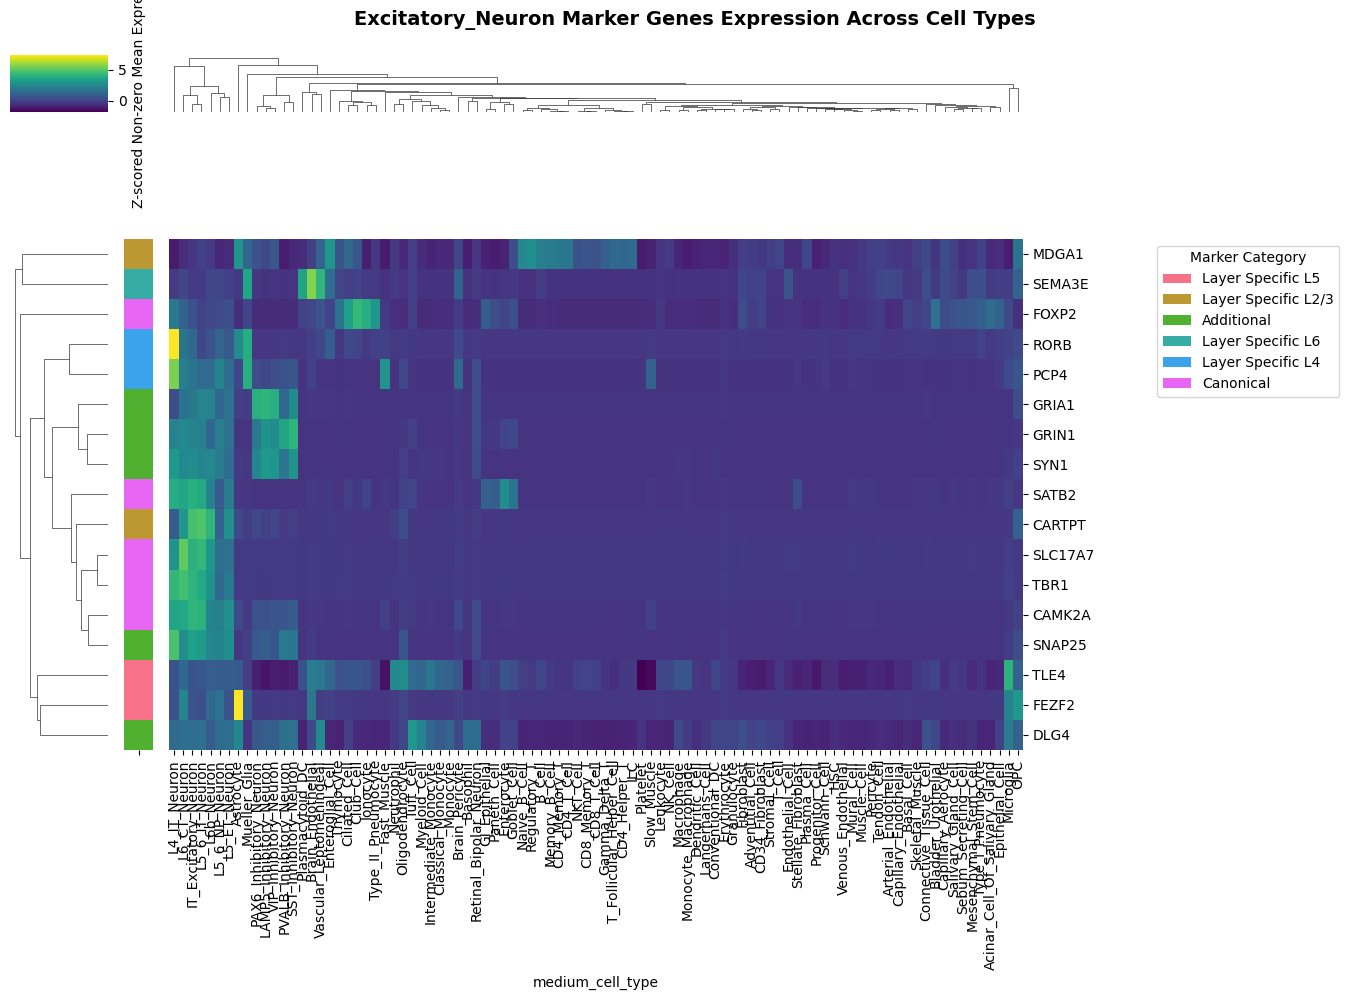


Creating heatmap for Inhibitory_Neuron...


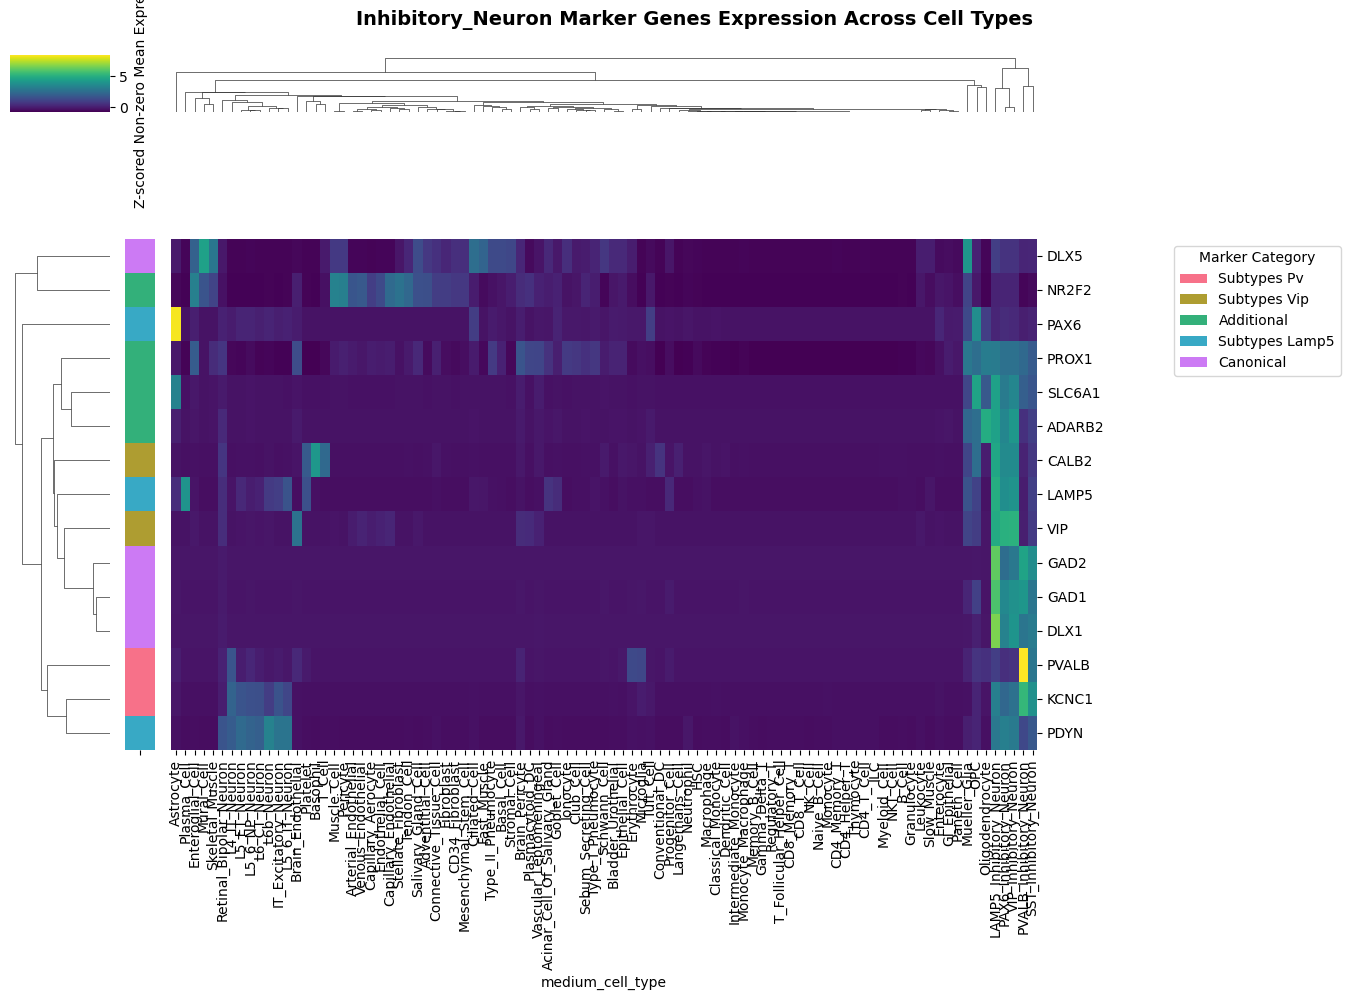


Creating heatmap for CNS_Glia...


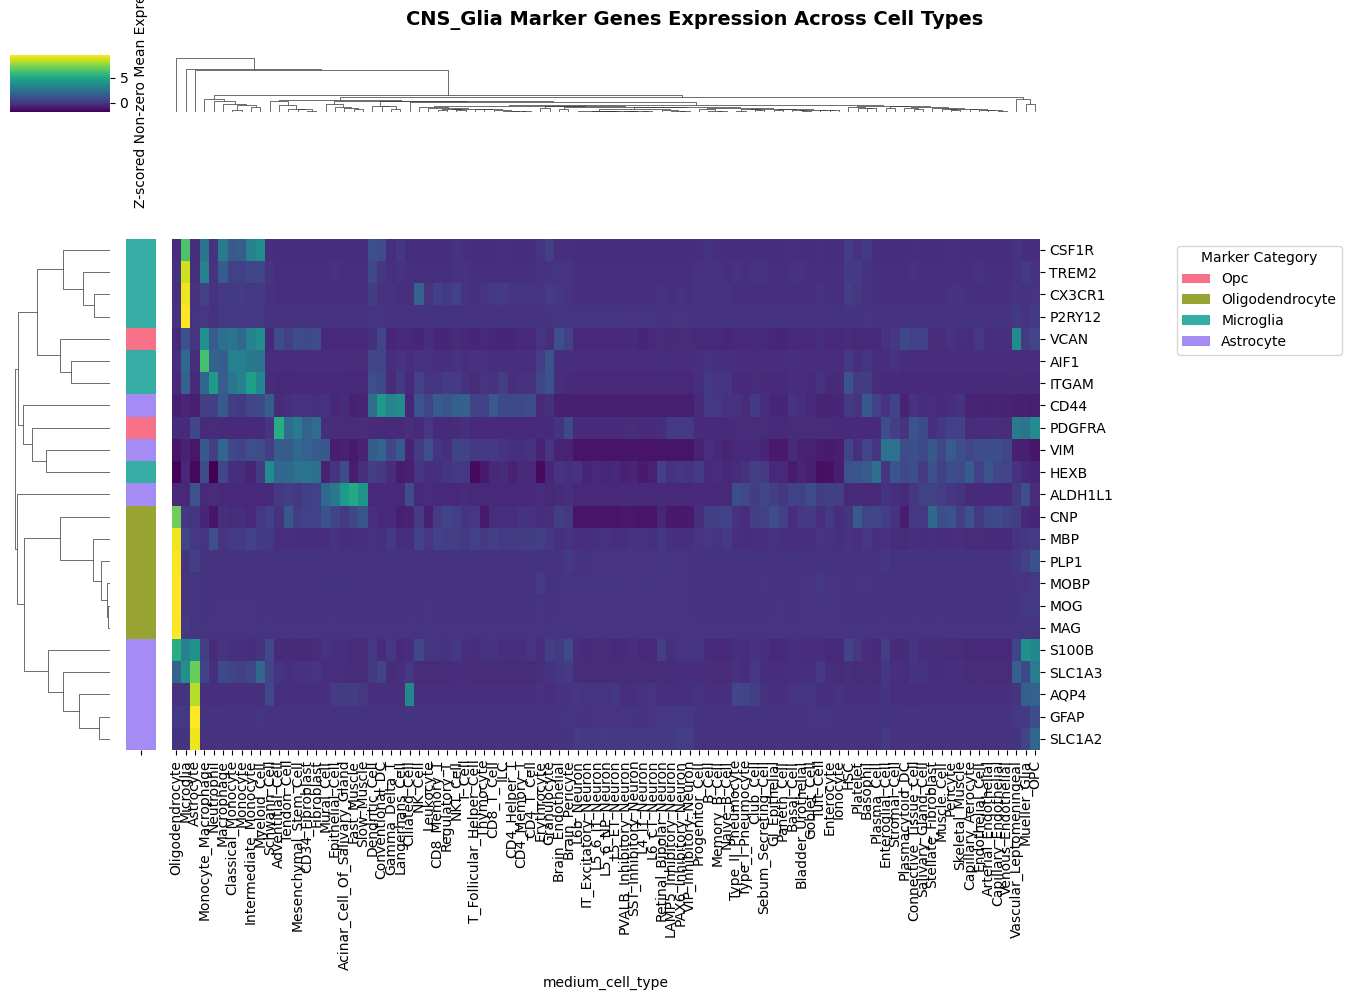


Creating heatmap for CD4_T_cell...


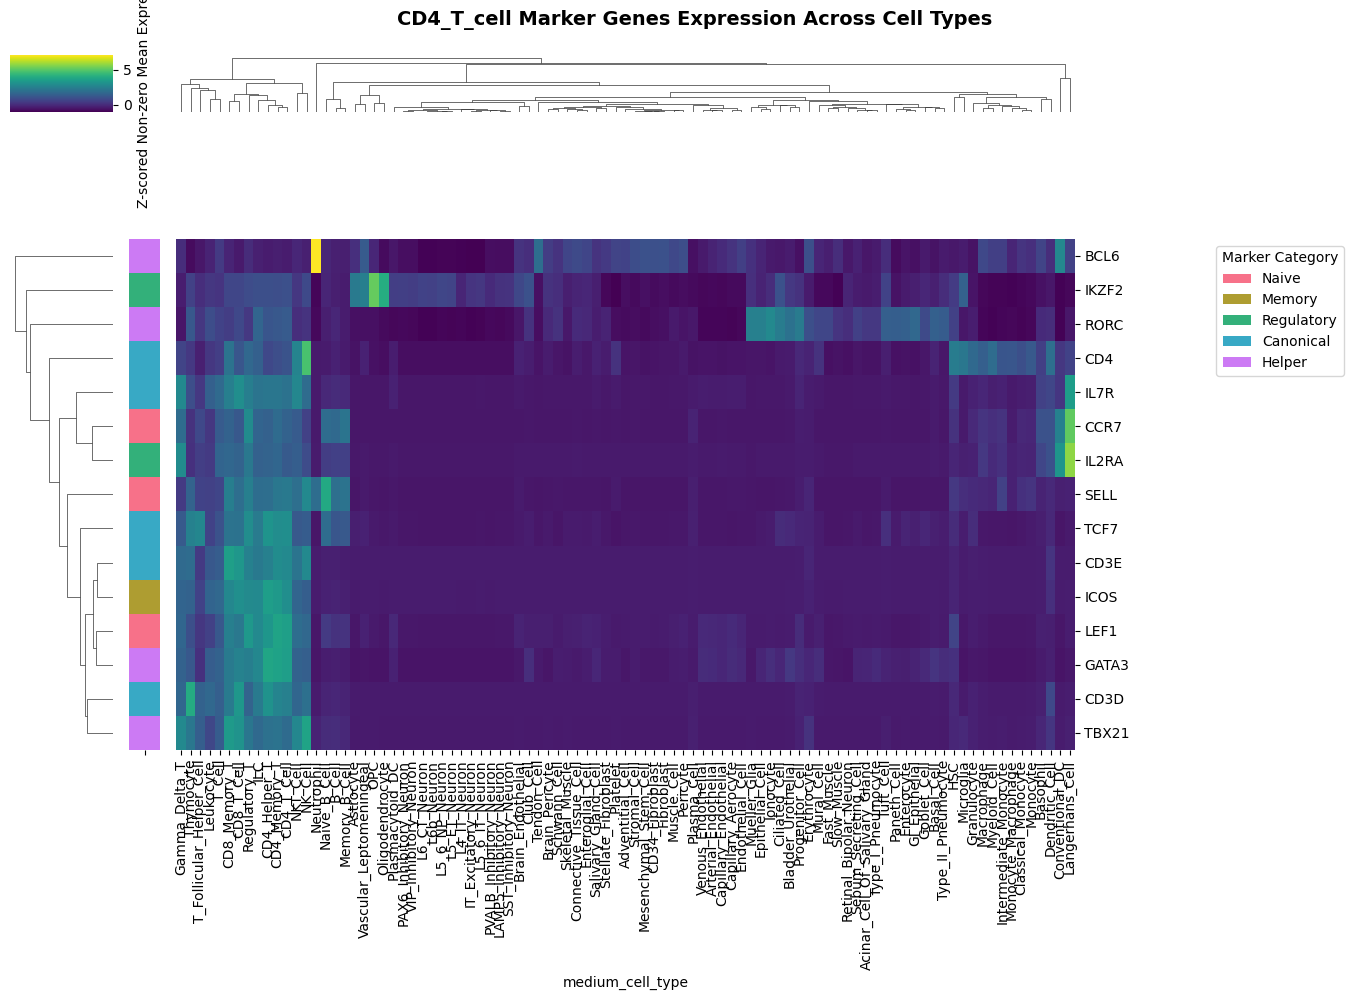


Creating heatmap for B_cell...


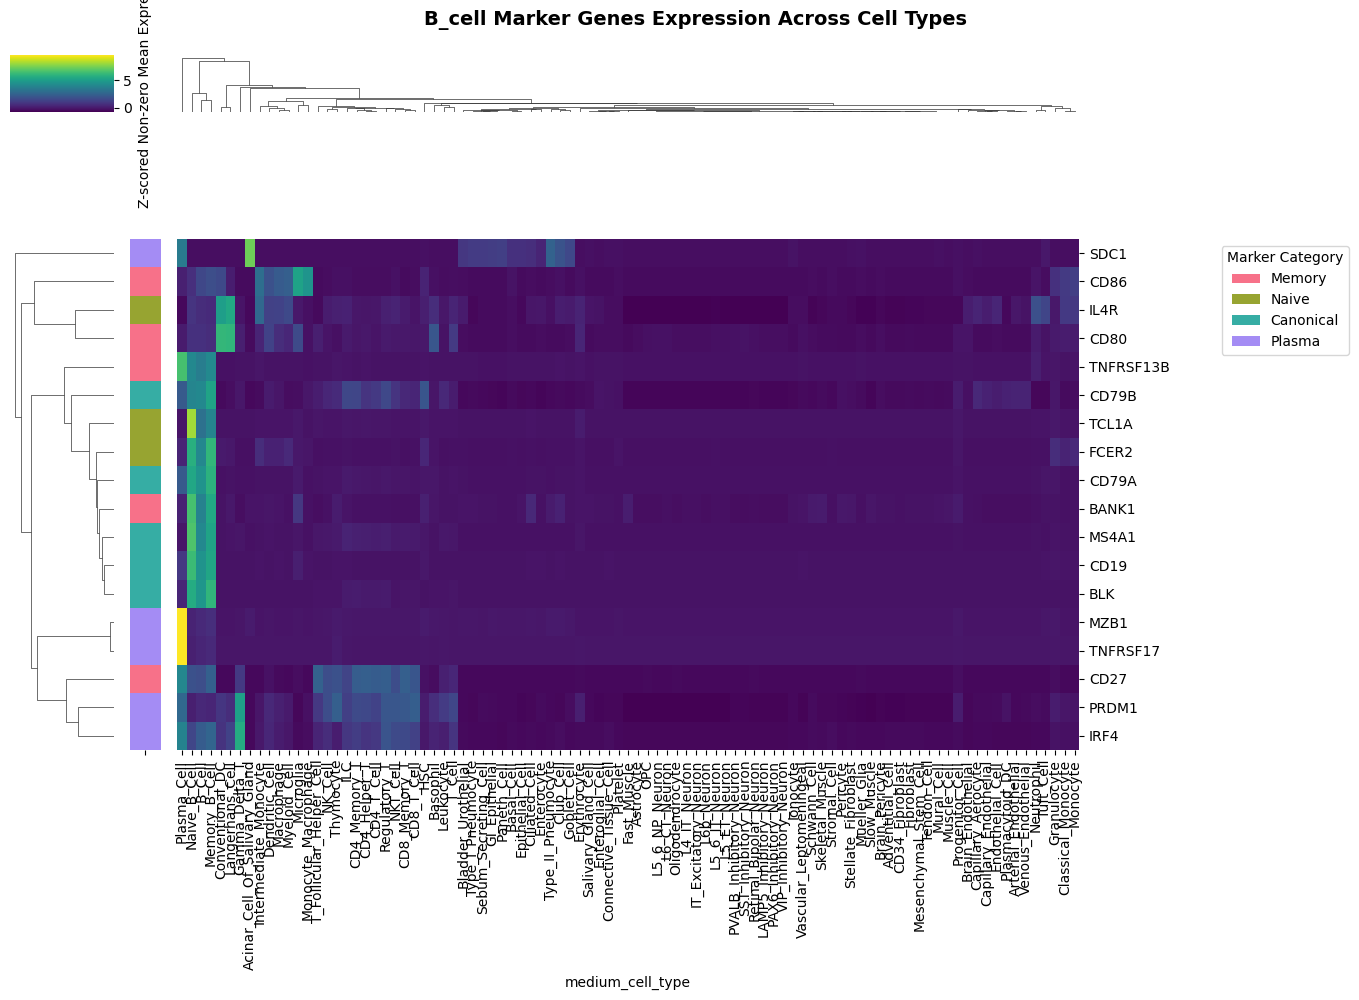


Creating heatmap for CD8_T_cell...


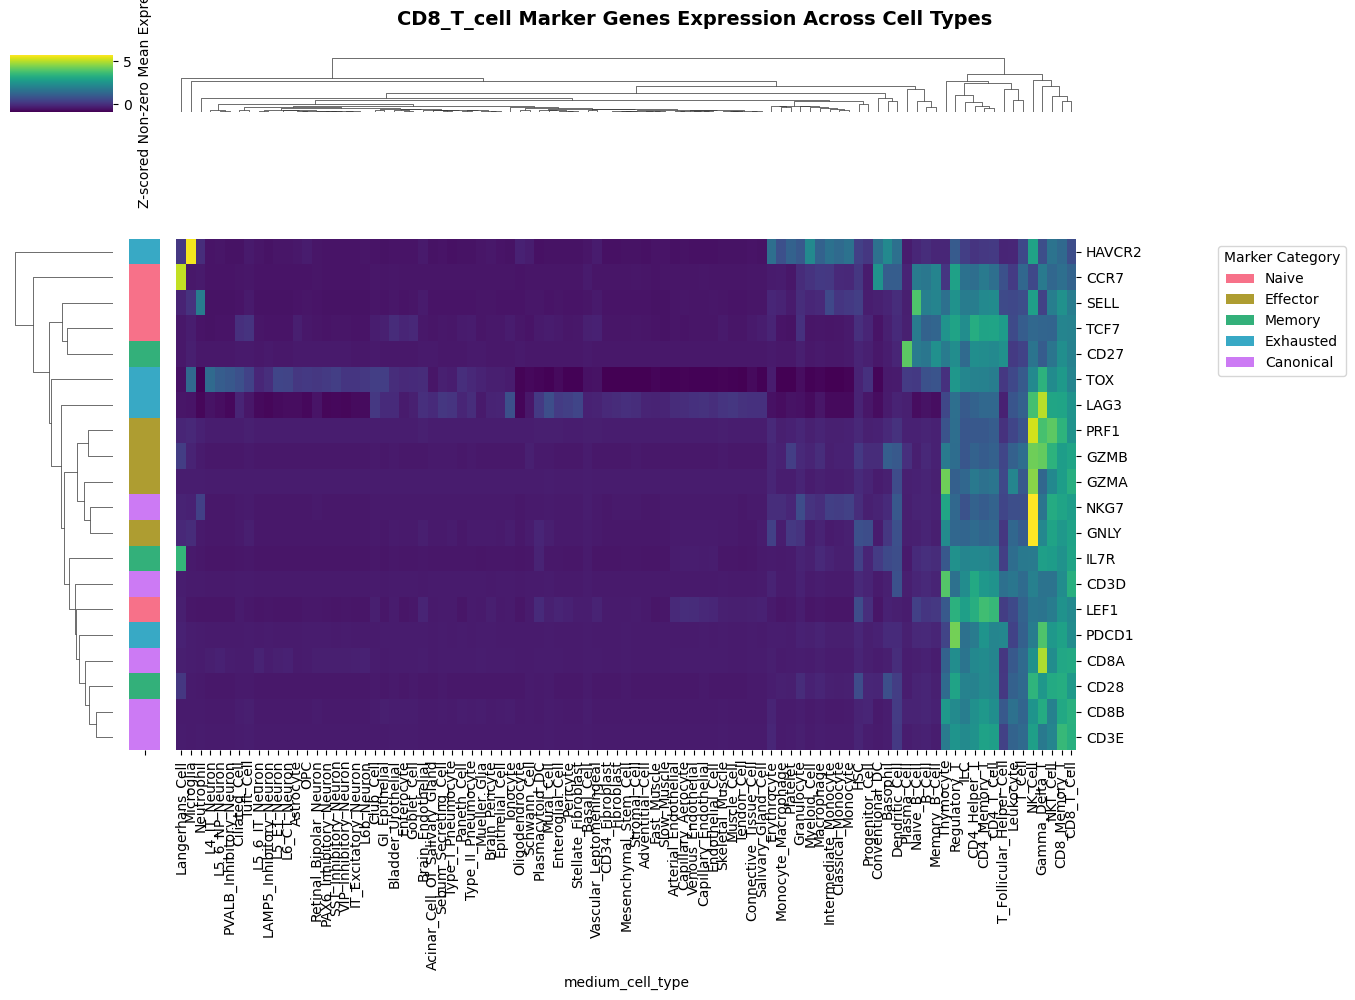

In [20]:
# Usage example:
# Get marker availability summary
marker_summary = get_marker_expression_summary(ge_adata)
print("\nMarker Gene Availability Summary:")
print(marker_summary[['total_markers', 'available_markers', 'percentage']])

# Create heatmaps for top 5 most abundant cell types
top_cell_types = ge_adata.obs['broad_cell_type'].value_counts().head(10).index.tolist()
create_all_cell_type_heatmaps(
    ge_adata,
    cell_types=top_cell_types,
    save_dir='/gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/GeneExpression/marker_gene_plots/'  # Optional: specify directory to save
)

In [21]:
# choose random gene and visualize its junctions observed counts, atse counts and PSI value (observed) versus overall gene counts 
ge_adata.var.sample(1)

,gene_symbol,gene_id,gene_name,mean_transcript_length,mean_intron_length,num_transcripts,gene_biotype,clean_gene_id,is_rRNA,n_cells_by_counts,...,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,RBP_gene,is_hvg,is_rbp,aging_gene,senescence_gene,high_confidence_aging_gene
gene_name,,,,,,,,,,,,,,,,,,,,,
FLYWCH1,FLYWCH1,ENSG00000059122.17,FLYWCH1,4348.545455,33894.909091,22,protein-coding,ENSG00000059122,False,19631,...,3.297926,77.267885,2250184.0,14.626523,False,True,False,False,False,False


In [22]:
splice_adata.var[splice_adata.var["gene_name"] == "RANGAP1"]

,junction_id,event_id,splice_motif,annotation_status,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,junction_id_index,clean_gene_id,gene_name,mean_transcript_length,mean_intron_length,num_transcripts,n_cells_detected,confidence,aging_gene,senescence_gene,high_confidence_aging_gene
78888,chr22_41258106_41261445_-,ENSG00000100401.21_atse_3,GT-AG,both,ENSG00000100401.21,5,1.0,0.0,44035,89563,ENSG00000100401,RANGAP1,3508.066667,36198.333333,30,1864,high,False,False,False
78889,chr22_41258106_41264663_-,ENSG00000100401.21_atse_3,GT-AG,both,ENSG00000100401.21,5,1.0,0.0,1116,89564,ENSG00000100401,RANGAP1,3508.066667,36198.333333,30,35,low,False,False,False
78890,chr22_41261580_41264663_-,ENSG00000100401.21_atse_3,GT-AG,both,ENSG00000100401.21,5,1.0,0.0,32508,89565,ENSG00000100401,RANGAP1,3508.066667,36198.333333,30,1605,high,False,False,False
78891,chr22_41261580_41268096_-,ENSG00000100401.21_atse_3,GT-AG,both,ENSG00000100401.21,5,1.0,0.0,1131,89566,ENSG00000100401,RANGAP1,3508.066667,36198.333333,30,30,low,False,False,False
78892,chr22_41264843_41268096_-,ENSG00000100401.21_atse_3,GT-AG,both,ENSG00000100401.21,5,1.0,0.0,30820,89567,ENSG00000100401,RANGAP1,3508.066667,36198.333333,30,1399,high,False,False,False
78893,chr22_41274727_41277882_-,ENSG00000100401.21_atse_2,GT-AG,three_prime,ENSG00000100401.21,2,NaN,0.0,365,89568,ENSG00000100401,RANGAP1,3508.066667,36198.333333,30,9,low,False,False,False
78894,chr22_41274727_41280932_-,ENSG00000100401.21_atse_2,GT-AG,both,ENSG00000100401.21,2,1.0,0.0,29759,89569,ENSG00000100401,RANGAP1,3508.066667,36198.333333,30,1379,high,False,False,False


In [23]:
import sys 
# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import *
from figure_plotting import *

# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
import sys
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *
import gffutils

gtf_file = "/gpfs/commons/groups/knowles_lab/Megan/encode_pacbio/paper_figures/isoform_gazers/all_samples_sp_collapse_all_chr_no_treatment_hashid_isoform_full.gtf"
db_file = "/gpfs/commons/groups/knowles_lab/Megan/encode_pacbio/paper_figures/isoform_gazers/long_read_hg38.db"
INTRON_CLUSTS_FILE = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/HUMAN_FOUNDATION_ATSE_FILE_unanno_also_2025-09-21_05-02-35.txt.gz"

# Load the database
db_human = gffutils.FeatureDB(db_file, keep_order=True)
atse_df = pd.read_csv(INTRON_CLUSTS_FILE, sep="\t")

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


Unique transcripts: ['ENST00000356244.8', 'ENST00000405486.5', 'ENST00000455915.6', 'ENST00000705116.1']
Unique transcripts to remove: ['s06fd0c905aeec442:e1693a8a50e90610e', 's0989dacbe6372735:e157f4d7ad7851547', 's19c4fc3c823e09fc:ea4f30dd4da3a933a', 's2f36998058d22ed9:ea4f30dd4da3a933a', 's2f52f014da91e59e:e56604e800ffc828b', 's34173c63e958fb79:e35561d883baace24', 's34173c63e958fb79:e66a1468205f565e2', 's4e8116849a984ab5:e5308d9b78695e9d6', 's5224ccf75547d1d7:e3806697c7e3d9d1c', 's5224ccf75547d1d7:e4c3c6fc254e239b1', 's5224ccf75547d1d7:edc00095b54483406', 's5224ccf75547d1d7:edf8fdb0330983a32', 's5224ccf75547d1d7:ef33acfdd87c8f2e2', 's69f824e1c96b69bd:e56604e800ffc828b', 's7087dafe1d89f978:ea4f30dd4da3a933a', 's7087dafe1d89f978:ebb32ef137b82c1bf', 's76aca4c5b20ec214:edb03bd38d1cc980b', 's8739a173839ec69e:e56604e800ffc828b', 'saa9178bba984952d:e3a47d26746c2331f', 'sc7a0a30f15628654:ea91ab36c5d8de09e', 'sc92799b46d2d86a7:eda46e7c746ca6f1d', 'sd0a1df93c881d6f3:e081ae31207404fe1', 'sdfc5

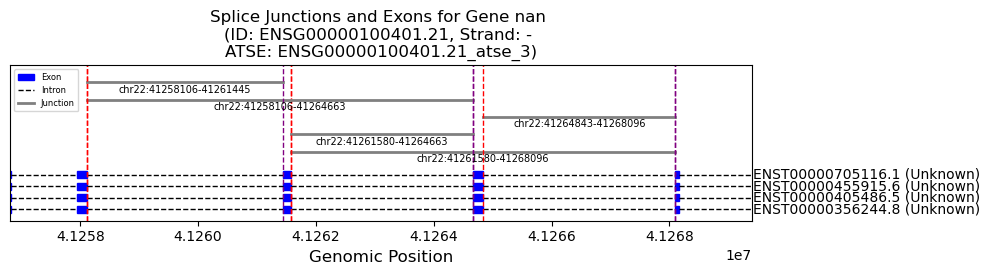

ATSE visualization saved: human_ENSG00000100401.21_atse_3.pdf


{'junctions':                         event_id             gene_id  gene_name  gene_types  \
 17571  ENSG00000100401.21_atse_3  ENSG00000100401.21        NaN         NaN   
 17572  ENSG00000100401.21_atse_3  ENSG00000100401.21        NaN         NaN   
 17573  ENSG00000100401.21_atse_3  ENSG00000100401.21        NaN         NaN   
 17574  ENSG00000100401.21_atse_3  ENSG00000100401.21        NaN         NaN   
 17575  ENSG00000100401.21_atse_3  ENSG00000100401.21        NaN         NaN   
 
        num_junctions event_type chromosome strand  atse_start  atse_end  ...  \
 17571              5    complex      chr22      -    41258106  41268096  ...   
 17572              5    complex      chr22      -    41258106  41268096  ...   
 17573              5    complex      chr22      -    41258106  41268096  ...   
 17574              5    complex      chr22      -    41258106  41268096  ...   
 17575              5    complex      chr22      -    41258106  41268096  ...   
 
        acceptor_

In [24]:
human_event = "ENSG00000100401.21_atse_3"
# need to fix by adding back columns to atse_df 
visualize_atse_event(human_event, atse_df, db_human,
                 species="human", base_width=10, 
                       trans_height=0.4, 
                  padding=300, show_junc_lines=True)

In [25]:
splice_adata.var["junction_id_index"] = range(splice_adata.var.shape[0])
splice_adata.var.reset_index(inplace=True)

In [26]:
splice_adata.obs.reset_index(drop=True, inplace=True)
splice_adata.obs["cell_id_index"] = splice_adata.obs.index
print(f"The number of cells in the dataset is {splice_adata.shape[0]}", flush=True)


The number of cells in the dataset is 76986


In [27]:
ge_adata.obs.reset_index(drop=True, inplace=True)
ge_adata.obs["cell_id_index"] = ge_adata.obs.index
print(f"The number of cells in the dataset is {ge_adata.shape[0]}", flush=True)

The number of cells in the dataset is 76986


In [28]:
splice_adata.obs["dataset"].value_counts()

dataset
allen_brain       45496
tabula_sapiens    31490
Name: count, dtype: int64

In [29]:
splice_adata.obs["sex"].value_counts()

sex
M    41345
F    35641
Name: count, dtype: int64

In [30]:
ge_adata.obs.iloc[0]

donor                                     H200.1030
sex                                               M
age                                              54
dataset                                 allen_brain
tissue                                          MTG
cell_type                                       SST
broad_cell_type                   Inhibitory_Neuron
library_size                               834740.0
batch                             allen_brain_exons
cell_id_backup                  F1S4_160106_001_B01
cell_id_index                                     0
cell_id_clean                   F1S4_160106_001_B01
n_genes_by_counts                              3675
log1p_n_genes_by_counts                     8.20958
total_counts                               736045.0
log1p_total_counts                        13.509048
total_counts_is_rRNA                            0.0
log1p_total_counts_is_rRNA                      0.0
pct_counts_is_rRNA                              0.0
_scvi_batch 

In [31]:
ge_adata.obs_names = ge_adata.obs["cell_id_clean"]
splice_adata.obs_names = splice_adata.obs["cell_id_clean"]

In [32]:
# assert that splice_adata.obs and ge_adata.obs are the same 
# Assert that obs_names are the same
assert np.all(ge_adata.obs_names == splice_adata.obs_names)
# Assert that the cells are in the same order
assert np.all(ge_adata.obs["cell_id_clean"].values == splice_adata.obs["cell_id_clean"].values) 

In [33]:
# Convert gene names to string type
splice_adata.var["gene_name"] = splice_adata.var["gene_name"].astype(str)
ge_adata.var["gene_name"] = ge_adata.var["gene_name"].astype(str)

# Create sets of gene names
splice_genes_set = set(splice_adata.var["gene_name"])
ge_genes_set = set(ge_adata.var["gene_name"])

# Find common genes
common_genes = splice_genes_set & ge_genes_set
print(f"Number of genes in splice_adata: {len(splice_genes_set)}")
print(f"Number of genes in ge_adata: {len(ge_genes_set)}")
print(f"Number of common genes: {len(common_genes)}")

# Subset both AnnData objects to only common genes
# Create boolean masks for rows where gene_name is in common_genes
splice_mask = splice_adata.var["gene_name"].isin(common_genes)
ge_mask = ge_adata.var["gene_name"].isin(common_genes)

# Subset the AnnData objects
splice_adata = splice_adata[:, splice_mask].copy()
ge_adata = ge_adata[:, ge_mask].copy()

print(f"\nAfter subsetting:")
print(f"splice_adata shape: {splice_adata.shape}")
print(f"ge_adata shape: {ge_adata.shape}")

# Verify they now have the same genes
print(f"\nVerification:")
print(f"Number of genes in splice_adata: {splice_adata.n_vars}")
print(f"Number of genes in ge_adata: {ge_adata.n_vars}")

Number of genes in splice_adata: 11545
Number of genes in ge_adata: 11545
Number of common genes: 11470

After subsetting:
splice_adata shape: (76986, 123383)
ge_adata shape: (76986, 11470)

Verification:
Number of genes in splice_adata: 123383
Number of genes in ge_adata: 11470


In [34]:
splice_adata.var["junction_id_index"] = range(splice_adata.var.shape[0])
splice_adata.var.reset_index(inplace=True)

In [35]:
print(f"Final number of genes in both datasets: {splice_adata.var['gene_name'].nunique()}")
print(f"Final number of ATSEs in both datasets: {splice_adata.var['event_id'].nunique()}")
print(f"Final number of Junctions in both datasets: {splice_adata.var['junction_id'].nunique()}")


Final number of genes in both datasets: 11470
Final number of ATSEs in both datasets: 35891
Final number of Junctions in both datasets: 123383


In [36]:
# Save final versions of the files 
import os
from datetime import datetime

# Set new model date and shared output directory
new_model_date = "102025"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
GE_OUTPUT_DIR = f"/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/{new_model_date}"
os.makedirs(GE_OUTPUT_DIR, exist_ok=True)

# ---- Gene Expression ----
ge_new_filename = f"model_ready_gene_expression_data_{timestamp}.h5ad"
GE_OUTPUT_PATH = os.path.join(GE_OUTPUT_DIR, ge_new_filename)

# Save filtered gene expression data
ge_adata.write(GE_OUTPUT_PATH, compression="lzf")
print(f"Filtered gene expression AnnData written to:\n{GE_OUTPUT_PATH}")

# ---- Splicing Data ----
splice_new_filename = f"model_ready_aligned_splicing_data_{timestamp}.h5ad"
SPLICE_OUTPUT_PATH = os.path.join(GE_OUTPUT_DIR, splice_new_filename)
# Subset and save matched splicing data
splice_adata.write(SPLICE_OUTPUT_PATH, compression="lzf")
print(f"Filtered splicing AnnData written to:\n{SPLICE_OUTPUT_PATH}")

Filtered gene expression AnnData written to:
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/102025/model_ready_gene_expression_data_20251009_023419.h5ad
Filtered splicing AnnData written to:
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/102025/model_ready_aligned_splicing_data_20251009_023419.h5ad
